# Discriminator Evaluation on GenImage

Tests **4 pretrained detectors** on 1000 AI-generated + 1000 real images per GenImage generator.

**Models**:
1. **SigLIP** (Ateeqq) — SigLIP fine-tune, 120K images
2. **Swin SDXL** (Organika) — Swin-Base, trained on SDXL
3. **NPR** (CVPR 2024) — Neighboring Pixel Relationships, truncated ResNet50
4. **CommFor** (CVPR 2025) — Community Forensics, ViT-Small trained on 4,803 generators

**Generators**: ADM, BigGAN, GLIDE, SDv5, VQDM

**Metrics** (threshold = 0.5):
- **Fake Acc (TPR)**: % of fake images correctly classified as fake
- **Real Acc (TNR)**: % of real images correctly classified as real
- **Overall Acc**: combined accuracy across both classes

## 1. Setup

In [1]:
import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm", "huggingface_hub"])

import os
import random
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

# Project paths
PROJECT_ROOT = Path("../../..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
DISC_DIR = Path(".").resolve()  # discriminator scripts directory

# Map directory name prefixes to readable generator labels
GENERATOR_MAP = {
    "imagenet_ai_0508_adm": "ADM",
    "imagenet_ai_0419_biggan": "BigGAN",
    "imagenet_glide": "GLIDE",
    "imagenet_ai_0424_sdv5": "SDv5",
    "imagenet_ai_0419_vqdm": "VQDM",
}

SAMPLE_SIZE = 1000
THRESHOLD = 0.5
IMAGE_EXTENSIONS = {".jpeg", ".jpg", ".png"}

random.seed(42)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir: {DATA_DIR}")
print(f"Data dir exists: {DATA_DIR.exists()}")

Project root: /Users/jaymes/cv_project/deepfake-it-till-you-make-it
Data dir: /Users/jaymes/cv_project/deepfake-it-till-you-make-it/data
Data dir exists: True


/Users/jaymes/miniconda3/envs/deepfake_it_tymi_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Discover Available Data

In [2]:
def find_images(base_dir, dir_prefix, subdir):
    """Find images across all directories matching a prefix.
    
    Handles split directories like 'imagenet_ai_0424_sdv5', 'imagenet_ai_0424_sdv5 2', etc.
    Looks for images in the given subdirectory ('ai' or 'nature') of each.
    """
    images = []
    for d in sorted(base_dir.iterdir()):
        if d.is_dir() and d.name.startswith(dir_prefix):
            sub = d / subdir
            if sub.exists():
                for f in sub.rglob("*"):
                    if f.suffix.lower() in IMAGE_EXTENSIONS and f.is_file():
                        images.append(f)
    return images


available_fake = {}
available_real = {}

for dir_prefix, label in GENERATOR_MAP.items():
    fake_imgs = find_images(DATA_DIR, dir_prefix, "ai")
    real_imgs = find_images(DATA_DIR, dir_prefix, "nature")
    
    if fake_imgs:
        available_fake[label] = fake_imgs
    if real_imgs:
        available_real[label] = real_imgs
    
    print(f"{label:>8}: {len(fake_imgs):>6} fake, {len(real_imgs):>6} real")

print(f"\nGenerators with fake data: {list(available_fake.keys())}")
print(f"Generators with real data: {list(available_real.keys())}")

     ADM:   6000 fake,   6000 real
  BigGAN:   6001 fake,   6000 real
   GLIDE:   6000 fake,   6000 real
    SDv5:   8000 fake,   8019 real
    VQDM:   6001 fake,   6007 real

Generators with fake data: ['ADM', 'BigGAN', 'GLIDE', 'SDv5', 'VQDM']
Generators with real data: ['ADM', 'BigGAN', 'GLIDE', 'SDv5', 'VQDM']


## 3. Sample 1000 Images Per Generator

In [3]:
sampled_data = []  # list of (generator, label, image_path) tuples

for gen in available_fake:
    # Sample fake images
    fake_imgs = available_fake[gen]
    n_fake = min(SAMPLE_SIZE, len(fake_imgs))
    for img in random.sample(fake_imgs, n_fake):
        sampled_data.append((gen, "fake", img))
    
    # Sample real images (if available for this generator)
    if gen in available_real:
        real_imgs = available_real[gen]
        n_real = min(SAMPLE_SIZE, len(real_imgs))
        for img in random.sample(real_imgs, n_real):
            sampled_data.append((gen, "real", img))
        print(f"{gen:>8}: {n_fake} fake + {n_real} real")
    else:
        print(f"{gen:>8}: {n_fake} fake + 0 real (no nature/ dir)")

print(f"\nTotal images to evaluate: {len(sampled_data)}")

     ADM: 1000 fake + 1000 real
  BigGAN: 1000 fake + 1000 real
   GLIDE: 1000 fake + 1000 real
    SDv5: 1000 fake + 1000 real
    VQDM: 1000 fake + 1000 real

Total images to evaluate: 10000


## 4. Load All Discriminator Models

In [ ]:
from transformers import AutoImageProcessor, AutoModelForImageClassification, SiglipForImageClassification
from torchvision import transforms
import timm
import torch.nn as nn
import torch.nn.functional as F
from huggingface_hub import PyTorchModelHubMixin
from math import ceil

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# --- 1. SigLIP Deepfake Detector ---
SIGLIP_ID = "Ateeqq/ai-vs-human-image-detector"
print(f"\nLoading SigLIP ({SIGLIP_ID})...")
siglip_processor = AutoImageProcessor.from_pretrained(SIGLIP_ID, use_fast=False)
siglip_model = SiglipForImageClassification.from_pretrained(SIGLIP_ID)
siglip_model.to(device).eval()
print("SigLIP loaded.")

# --- 2. Swin SDXL Detector ---
SWIN_ID = "Organika/sdxl-detector"
print(f"\nLoading Swin SDXL ({SWIN_ID})...")
swin_processor = AutoImageProcessor.from_pretrained(SWIN_ID, use_fast=False)
swin_model = AutoModelForImageClassification.from_pretrained(SWIN_ID)
swin_model.to(device).eval()
print("Swin SDXL loaded.")

# --- 3. NPR (CVPR 2024) ---
from npr_inference import NPRResNet, load_model as npr_load_model

NPR_WEIGHTS = DISC_DIR / "weights" / "NPR.pth"
print(f"\nLoading NPR ({NPR_WEIGHTS})...")
assert NPR_WEIGHTS.exists(), f"NPR weights not found at {NPR_WEIGHTS}. Download from: https://drive.google.com/drive/folders/1_mD17F94xMbJqEAsWRW1gVsZ5db6YamI"
npr_model_tuple, _ = npr_load_model(NPR_WEIGHTS)
npr_model, npr_transform = npr_model_tuple
npr_model = npr_model.to(device)
print("NPR loaded.")

# --- 4. Community Forensics (CVPR 2025) ---
from community_forensics_inference import _build_model_class

COMMFOR_REPO = "OwensLab/commfor-model-384"
print(f"\nLoading Community Forensics ({COMMFOR_REPO})...")
ViTClassifier = _build_model_class()
commfor_model = ViTClassifier.from_pretrained(COMMFOR_REPO)
commfor_model.to(device).eval()
commfor_transform = transforms.Compose([
    transforms.Resize(440, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
print("Community Forensics loaded.")

print("\nAll 4 models loaded.")

## 5. Evaluate All Models

In [5]:
def score_hf_model(image_path, model, processor, fake_class, device):
    """Score using a HuggingFace transformers model. Returns fakeness prob."""
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=1)
        return probs[0, fake_class].item()


def score_timm_model(image_path, model, transform, device):
    """Score using a timm/custom model with sigmoid output. Returns fakeness prob."""
    image = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        logit = model(tensor)
        return torch.sigmoid(logit).item()


results = []

for gen, label, img_path in tqdm(sampled_data, desc="Scoring"):
    try:
        results.append({
            "generator": gen,
            "label": label,
            "image": str(img_path.name),
            "siglip_score": score_hf_model(img_path, siglip_model, siglip_processor, 0, device),
            "swin_score": score_hf_model(img_path, swin_model, swin_processor, 0, device),
            "npr_score": score_timm_model(img_path, npr_model, npr_transform, device),
            "commfor_score": score_timm_model(img_path, commfor_model, commfor_transform, device),
        })
    except Exception as e:
        print(f"  Error on {img_path.name}: {e}")

df = pd.DataFrame(results)
print(f"\nEvaluation complete. {len(df)} images scored.")
print(f"  Fake: {(df['label'] == 'fake').sum()}, Real: {(df['label'] == 'real').sum()}")

Scoring: 100%|██████████| 10000/10000 [56:19<00:00,  2.96it/s]


Evaluation complete. 10000 images scored.
  Fake: 5000, Real: 5000


## 6. Results: Accuracy Per Generator

In [6]:
MODEL_COLS = {
    "siglip": "SigLIP",
    "swin": "Swin SDXL",
    "npr": "NPR",
    "commfor": "CommFor",
}

# Correct prediction: fake images should score > threshold, real images should score <= threshold
for key in MODEL_COLS:
    df[f"{key}_correct"] = (
        ((df["label"] == "fake") & (df[f"{key}_score"] > THRESHOLD)) |
        ((df["label"] == "real") & (df[f"{key}_score"] <= THRESHOLD))
    )

# --- Per-generator results ---
rows = []
for gen in df["generator"].unique():
    gen_df = df[df["generator"] == gen]
    row = {"generator": gen, "n_fake": (gen_df["label"] == "fake").sum(), "n_real": (gen_df["label"] == "real").sum()}
    for key, label in MODEL_COLS.items():
        fake_mask = gen_df["label"] == "fake"
        real_mask = gen_df["label"] == "real"
        row[f"{label}_TPR"] = gen_df.loc[fake_mask, f"{key}_correct"].mean() if fake_mask.any() else None
        row[f"{label}_TNR"] = gen_df.loc[real_mask, f"{key}_correct"].mean() if real_mask.any() else None
        row[f"{label}_acc"] = gen_df[f"{key}_correct"].mean()
    rows.append(row)

# Overall row
overall = {"generator": "OVERALL", "n_fake": (df["label"] == "fake").sum(), "n_real": (df["label"] == "real").sum()}
for key, label in MODEL_COLS.items():
    fake_mask = df["label"] == "fake"
    real_mask = df["label"] == "real"
    overall[f"{label}_TPR"] = df.loc[fake_mask, f"{key}_correct"].mean()
    overall[f"{label}_TNR"] = df.loc[real_mask, f"{key}_correct"].mean()
    overall[f"{label}_acc"] = df[f"{key}_correct"].mean()
rows.append(overall)

accuracy_table = pd.DataFrame(rows).set_index("generator")

# Format as percentages for display
display_table = accuracy_table.copy()
for label in MODEL_COLS.values():
    for metric in ["TPR", "TNR", "acc"]:
        col = f"{label}_{metric}"
        display_table[col] = display_table[col].map(lambda x: f"{x*100:.2f}%" if pd.notna(x) else "N/A")

print("Discriminator Evaluation Results (threshold = 0.5)")
print("TPR = fake detected as fake | TNR = real detected as real | acc = overall")
print("=" * 120)
display(display_table)

Discriminator Evaluation Results (threshold = 0.5)
TPR = fake detected as fake | TNR = real detected as real | acc = overall


,n_fake,n_real,SigLIP_TPR,SigLIP_TNR,SigLIP_acc,Swin SDXL_TPR,Swin SDXL_TNR,Swin SDXL_acc,NPR_TPR,NPR_TNR,NPR_acc,CommFor_TPR,CommFor_TNR,CommFor_acc
generator,,,,,,,,,,,,,,
ADM,1000,1000,18.50%,81.90%,50.20%,31.20%,88.00%,59.60%,88.30%,23.50%,55.90%,93.10%,6.50%,49.80%
BigGAN,1000,1000,18.90%,82.40%,50.65%,15.90%,88.60%,52.25%,98.90%,23.50%,61.20%,91.50%,7.60%,49.55%
GLIDE,1000,1000,49.70%,79.80%,64.75%,58.20%,88.60%,73.40%,99.40%,24.40%,61.90%,92.60%,7.40%,50.00%
SDv5,1000,1000,50.90%,81.10%,66.00%,42.70%,86.90%,64.80%,96.70%,25.00%,60.85%,93.80%,7.00%,50.40%
VQDM,1000,1000,21.60%,81.30%,51.45%,4.80%,88.10%,46.45%,93.50%,23.20%,58.35%,87.20%,7.50%,47.35%
OVERALL,5000,5000,31.92%,81.30%,56.61%,30.56%,88.04%,59.30%,95.36%,23.92%,59.64%,91.64%,7.20%,49.42%


## 7. Visualization

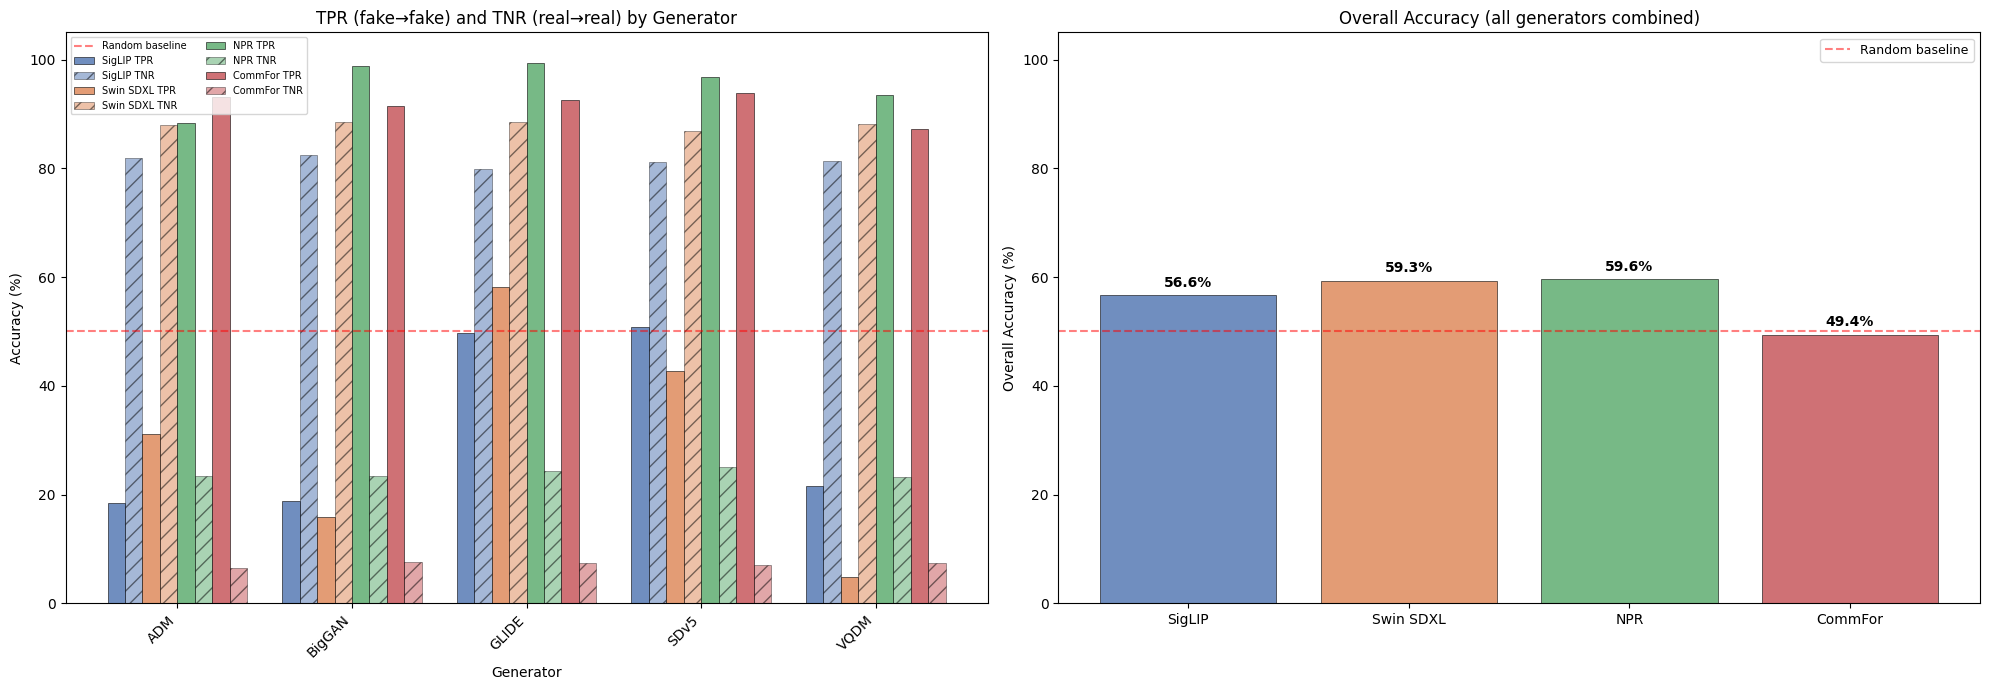

Figure saved to discriminator_evaluation_results.png


In [7]:
generators = [g for g in accuracy_table.index if g != "OVERALL"]
model_labels = list(MODEL_COLS.values())
colors = {"SigLIP": "#4C72B0", "Swin SDXL": "#DD8452", "NPR": "#55A868", "CommFor": "#C44E52"}

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- Bar chart: TPR and TNR per generator ---
x = range(len(generators))
n_bars = len(model_labels) * 2  # TPR + TNR per model
width = 0.8 / n_bars
bar_idx = 0

for label in model_labels:
    for metric, hatch in [("TPR", None), ("TNR", "//")]:
        col = f"{label}_{metric}"
        vals = [accuracy_table.loc[g, col] * 100 if pd.notna(accuracy_table.loc[g, col]) else 0 for g in generators]
        offset = (bar_idx - n_bars / 2 + 0.5) * width
        axes[0].bar([xi + offset for xi in x], vals, width, label=f"{label} {metric}",
                     color=colors[label], hatch=hatch, alpha=0.8 if hatch is None else 0.5,
                     edgecolor="black", linewidth=0.5)
        bar_idx += 1

axes[0].axhline(y=50, color="red", linestyle="--", alpha=0.5, label="Random baseline")
axes[0].set_xlabel("Generator")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("TPR (fake→fake) and TNR (real→real) by Generator")
axes[0].set_xticks(x)
axes[0].set_xticklabels(generators, rotation=45, ha="right")
axes[0].set_ylim(0, 105)
axes[0].legend(fontsize=7, ncol=2)

# --- Bar chart: Overall accuracy comparison ---
overall_accs = [accuracy_table.loc["OVERALL", f"{label}_acc"] * 100 for label in model_labels]
bar_colors = [colors[label] for label in model_labels]
bars = axes[1].bar(model_labels, overall_accs, color=bar_colors, alpha=0.8, edgecolor="black", linewidth=0.5)
axes[1].axhline(y=50, color="red", linestyle="--", alpha=0.5, label="Random baseline")
axes[1].set_ylabel("Overall Accuracy (%)")
axes[1].set_title("Overall Accuracy (all generators combined)")
axes[1].set_ylim(0, 105)
for bar, val in zip(bars, overall_accs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("discriminator_evaluation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to discriminator_evaluation_results.png")

## 8. Save Raw Results

In [8]:
csv_path = "discriminator_evaluation_scores.csv"
df.to_csv(csv_path, index=False)
print(f"Raw scores saved to {csv_path}")
print(f"\nSummary:")
print(f"  Total images evaluated: {len(df)} ({(df['label']=='fake').sum()} fake, {(df['label']=='real').sum()} real)")
print(f"  Generators tested: {df['generator'].nunique()}")
for key, label in MODEL_COLS.items():
    tpr = df.loc[df["label"] == "fake", f"{key}_correct"].mean()
    tnr = df.loc[df["label"] == "real", f"{key}_correct"].mean()
    acc = df[f"{key}_correct"].mean()
    print(f"  {label:>10}: TPR={tpr:.2%}, TNR={tnr:.2%}, Overall={acc:.2%}")

Raw scores saved to discriminator_evaluation_scores.csv

Summary:
  Total images evaluated: 10000 (5000 fake, 5000 real)
  Generators tested: 5
      SigLIP: TPR=31.92%, TNR=81.30%, Overall=56.61%
   Swin SDXL: TPR=30.56%, TNR=88.04%, Overall=59.30%
         NPR: TPR=95.36%, TNR=23.92%, Overall=59.64%
     CommFor: TPR=91.64%, TNR=7.20%, Overall=49.42%
